# Stability check / blend / V224
**Point 1** - multi-seed stability  
**Point 2** - ensemble blend  
**Point 3** - V224 as additional candidate

In [1]:
import ast, json, os, time
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict


In [2]:
ON_KAGGLE = os.path.exists("/kaggle")
DATA_DIR  = Path("/kaggle/input/datasets/bolesawpaliwoda/aml-project-2/data" if ON_KAGGLE else "data")
OUT_DIR   = Path("/kaggle/working" if ON_KAGGLE else ".")

TRAIN_X = DATA_DIR / "x_train_scaled_reduced_after_mi.csv"
TRAIN_Y = DATA_DIR / "y_train.txt"
CV_FOLDS, CAP = 5, 1000

BEST_K6_FEATS = ["V176", "V255", "V191", "V160", "V380", "V342"]
BEST_K5_FEATS = ["V255", "V191", "V215", "V380", "V342"]
BEST_K6_HP    = {"n_estimators": 214, "max_depth": 12, "min_samples_split": 9,
                  "min_samples_leaf": 8,  "criterion": "gini",    "class_weight": "balanced"}
BEST_K5_HP    = {"n_estimators": 234, "max_depth": 6,  "min_samples_split": 6,
                  "min_samples_leaf": 1,  "criterion": "entropy", "class_weight": "balanced"}

BLEND_HPS = [
    {"n_estimators": 214, "max_depth": 12, "min_samples_split": 9, "min_samples_leaf": 8, "criterion": "gini",    "class_weight": "balanced"},
    {"n_estimators": 419, "max_depth": 6,  "min_samples_split": 7, "min_samples_leaf": 2, "criterion": "gini",    "class_weight": "balanced"},
    {"n_estimators": 267, "max_depth": 5,  "min_samples_split": 6, "min_samples_leaf": 1, "criterion": "entropy", "class_weight": None},
    {"n_estimators": 158, "max_depth": 3,  "min_samples_split": 7, "min_samples_leaf": 3, "criterion": "gini",    "class_weight": None},
]

SEEDS        = [0, 1, 2, 42, 123]
CANDIDATES_8 = ["V176", "V255", "V191", "V160", "V215", "V380", "V342", "V224"]


In [3]:
def sweep_cutoff(y_true, p, n_vars, cap=CAP):
    order = np.argsort(-p)
    best_s, best_n = -np.inf, 0
    for n in range(1, min(cap, len(p)) + 1):
        tp = int(np.sum(y_true[order[:n]] == 1))
        s  = tp * 10 - (n - tp) * 5 - n_vars * 200
        if s > best_s:
            best_s, best_n = s, n
    if best_n == 0:
        return int(best_s), 0, 0.0, 0, 0
    tp_best = int(np.sum(y_true[order[:best_n]] == 1))
    return int(best_s), best_n, float(p[order[best_n-1]]), tp_best, best_n - tp_best

def get_oof_proba(X_arr, y, hp, random_state=0):
    model = ExtraTreesClassifier(**hp, random_state=random_state, n_jobs=-1)
    skf   = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=random_state)
    return cross_val_predict(model, X_arr, y, cv=skf, method="predict_proba", n_jobs=1)[:, 1]


In [4]:
X_df = pd.read_csv(TRAIN_X)
y    = np.loadtxt(TRAIN_Y, skiprows=1).astype(int)
print(f"X_train {X_df.shape}   positive rate {y.mean():.3f}")


X_train (5000, 493)   positive rate 0.498


## Point 1 - Multi-seed stability

In [5]:
configs = [
    ("k6_best", BEST_K6_FEATS, BEST_K6_HP),
    ("k5_best", BEST_K5_FEATS, BEST_K5_HP),
]

stability_rows = []
t0 = time.time()

for name, feats, hp in configs:
    k     = len(feats)
    X_arr = X_df[feats].to_numpy()
    print(f"\n{name}  k={k}  {feats}")
    for seed in SEEDS:
        p     = get_oof_proba(X_arr, y, hp, random_state=seed)
        score, N, thr, tp, fp = sweep_cutoff(y, p, k)
        print(f"  seed={seed:3d}  score={score}  N={N}  TP={tp}  FP={fp}")
        stability_rows.append(dict(name=name, k=k, features=str(feats), seed=seed,
                                   score=score, N=N, tp=tp, fp=fp))

stability_df = pd.DataFrame(stability_rows)
stability_df.to_csv(OUT_DIR / "stability_results.csv", index=False)
print(f"\nDone  ({(time.time()-t0)/60:.1f} min)  →  stability_results.csv")



k6_best  k=6  ['V176', 'V255', 'V191', 'V160', 'V380', 'V342']
  seed=  0  score=5685  N=999  TP=792  FP=207
  seed=  1  score=5425  N=1000  TP=775  FP=225
  seed=  2  score=5480  N=992  TP=776  FP=216
  seed= 42  score=5565  N=999  TP=784  FP=215
  seed=123  score=5455  N=997  TP=776  FP=221

k5_best  k=5  ['V255', 'V191', 'V215', 'V380', 'V342']
  seed=  0  score=5630  N=999  TP=775  FP=224
  seed=  1  score=5390  N=993  TP=757  FP=236
  seed=  2  score=5355  N=1000  TP=757  FP=243
  seed= 42  score=5265  N=997  TP=750  FP=247
  seed=123  score=5565  N=997  TP=770  FP=227

Done  (0.6 min)  →  stability_results.csv


,mean,std,min,max
name,,,,
k5_best,5441.0,151.7,5265,5630
k6_best,5522.0,105.0,5425,5685


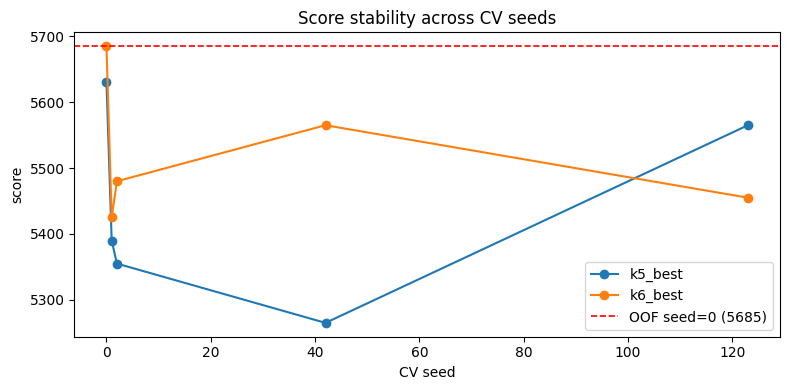

In [6]:
summary_stab = (stability_df.groupby("name")["score"]
                .agg(mean="mean", std="std", min="min", max="max")
                .round(1))
display(summary_stab)

fig, ax = plt.subplots(figsize=(8, 4))
for name, grp in stability_df.groupby("name"):
    ax.plot(grp["seed"], grp["score"], marker="o", label=name)
ax.axhline(5685, color="red", linestyle="--", lw=1.2, label="OOF seed=0 (5685)")
ax.set_xlabel("CV seed"); ax.set_ylabel("score")
ax.set_title("Score stability across CV seeds"); ax.legend()
plt.tight_layout(); plt.show()


## Point 2 - Ensemble blend on k=6 features

In [7]:
feats = BEST_K6_FEATS
k     = len(feats)
X_arr = X_df[feats].to_numpy()

print(f"OOF probs for {len(BLEND_HPS)} HP configs on {feats}")
proba_list    = []
blend_rows    = []

for i, hp in enumerate(BLEND_HPS):
    p = get_oof_proba(X_arr, y, hp, random_state=0)
    score, N, thr, tp, fp = sweep_cutoff(y, p, k)
    proba_list.append(p)
    print(f"  Config {i+1}: score={score}  N={N}  TP={tp}")
    blend_rows.append(dict(label=f"single_{i+1}", n_models=1,
                           score=score, N=N, tp=tp, fp=fp))

for n in range(2, len(proba_list) + 1):
    p_avg = np.mean(proba_list[:n], axis=0)
    score, N, thr, tp, fp = sweep_cutoff(y, p_avg, k)
    print(f"  Blend top-{n}:  score={score}  N={N}  TP={tp}")
    blend_rows.append(dict(label=f"blend_top{n}", n_models=n,
                           score=score, N=N, tp=tp, fp=fp))

blend_df = pd.DataFrame(blend_rows).sort_values("score", ascending=False).reset_index(drop=True)
blend_df.to_csv(OUT_DIR / "blend_results.csv", index=False)
print(f"\nSaved blend_results.csv")


OOF probs for 4 HP configs on ['V176', 'V255', 'V191', 'V160', 'V380', 'V342']
  Config 1: score=5685  N=999  TP=792
  Config 2: score=5580  N=999  TP=785
  Config 3: score=5470  N=1000  TP=778
  Config 4: score=5455  N=997  TP=776
  Blend top-2:  score=5635  N=1000  TP=789
  Blend top-3:  score=5530  N=997  TP=781
  Blend top-4:  score=5555  N=995  TP=782

Saved blend_results.csv


,label,n_models,score,N,tp,fp
0,single_1,1,5685,999,792,207
1,blend_top2,2,5635,1000,789,211
2,single_2,1,5580,999,785,214
3,blend_top4,4,5555,995,782,213
4,blend_top3,3,5530,997,781,216
5,single_3,1,5470,1000,778,222
6,single_4,1,5455,997,776,221


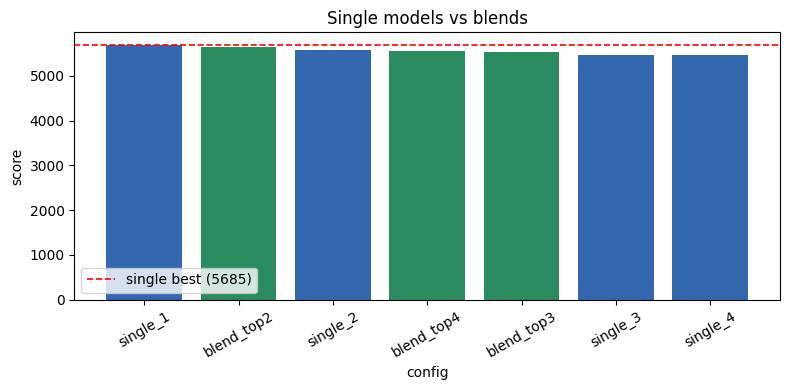

In [8]:
display(blend_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(blend_df["label"], blend_df["score"], color=["#2a8a60" if r["n_models"]>1 else "#3266ad"
       for _, r in blend_df.iterrows()])
ax.axhline(5685, color="red", linestyle="--", lw=1.2, label="single best (5685)")
ax.set_xlabel("config"); ax.set_ylabel("score"); ax.set_title("Single models vs blends")
ax.tick_params(axis="x", rotation=30); ax.legend()
plt.tight_layout(); plt.show()


## Point 3 - V224 as additional candidate

In [ ]:
other_7 = [c for c in CANDIDATES_8 if c != "V224"]

v224_subsets = []
for k_val in [5, 6]:
    for combo in combinations(other_7, k_val - 1):
        v224_subsets.append(["V224"] + list(combo))

print(f"{len(v224_subsets)} subsets containing V224 x {len(BLEND_HPS)} HP configs")

v224_rows = []
t0 = time.time()

for i, feats in enumerate(v224_subsets):
    k     = len(feats)
    X_arr = X_df[feats].to_numpy()
    best  = None
    for hp in BLEND_HPS:
        p = get_oof_proba(X_arr, y, hp, random_state=0)
        score, N, thr, tp, fp = sweep_cutoff(y, p, k)
        if best is None or score > best["score"]:
            best = dict(score=score, k=k, N=N, tp=tp, fp=fp,
                        features=str(sorted(feats)))
    v224_rows.append(best)
    if (i + 1) % 14 == 0 or i < 3:
        eta = (time.time() - t0) / (i + 1) * (len(v224_subsets) - i - 1)
        print(f"  [{i+1:2d}/{len(v224_subsets)}]  {sorted(feats)}  "
              f"score={best['score']}  ETA {eta/60:.1f}min")

v224_df = (pd.DataFrame(v224_rows)
           .sort_values("score", ascending=False)
           .reset_index(drop=True))
v224_df.to_csv(OUT_DIR / "v224_results.csv", index=False)
print(f"\nDone  ({(time.time()-t0)/60:.1f} min)  →  v224_results.csv")


56 subsets containing V224 × 4 HP configs
  [ 1/56]  ['V160', 'V176', 'V191', 'V224', 'V255']  score=5145  ETA 16.0min
  [ 2/56]  ['V176', 'V191', 'V215', 'V224', 'V255']  score=5130  ETA 15.5min
  [ 3/56]  ['V176', 'V191', 'V224', 'V255', 'V380']  score=5060  ETA 15.0min
  [14/56]  ['V176', 'V191', 'V215', 'V224', 'V380']  score=5055  ETA 11.8min
  [28/56]  ['V160', 'V215', 'V224', 'V255', 'V342']  score=5100  ETA 8.3min
  [42/56]  ['V160', 'V176', 'V215', 'V224', 'V255', 'V380']  score=5125  ETA 4.2min
  [56/56]  ['V160', 'V191', 'V215', 'V224', 'V342', 'V380']  score=5095  ETA 0.0min

Done  (16.5 min)  →  v224_results.csv


In [10]:
print("Top-10 subsets with V224:")
display(v224_df.head(10)[["score","k","N","tp","fp","features"]])

best_v224_score = v224_df.iloc[0]["score"]
delta = best_v224_score - 5685
print(f"\nBest with V224: {best_v224_score}  (vs current best 5685:  {delta:+d})")


Top-10 subsets with V224:


,score,k,N,tp,fp,features
0,5305,5,995,752,243,"['V160', 'V215', 'V224', 'V342', 'V380']"
1,5290,6,1000,766,234,"['V191', 'V215', 'V224', 'V255', 'V342', 'V380']"
2,5265,6,996,763,233,"['V160', 'V176', 'V191', 'V224', 'V255', 'V342']"
3,5200,6,1000,760,240,"['V160', 'V176', 'V191', 'V224', 'V255', 'V380']"
4,5190,5,1000,746,254,"['V160', 'V176', 'V215', 'V224', 'V342']"
5,5190,5,1000,746,254,"['V191', 'V215', 'V224', 'V255', 'V342']"
6,5175,5,1000,745,255,"['V160', 'V191', 'V224', 'V255', 'V380']"
7,5170,5,998,744,254,"['V160', 'V176', 'V191', 'V224', 'V380']"
8,5170,6,1000,758,242,"['V160', 'V191', 'V224', 'V255', 'V342', 'V380']"
9,5165,5,999,744,255,"['V160', 'V176', 'V191', 'V215', 'V224']"



Best with V224: 5305  (vs current best 5685:  -380)


## Summary

In [11]:
stab_k6 = stability_df[stability_df["name"] == "k6_best"]["score"]
stab_k5 = stability_df[stability_df["name"] == "k5_best"]["score"]

summary = {
    "seed0_best":           5685,
    "k6_mean":              round(float(stab_k6.mean()), 1),
    "k6_std":               round(float(stab_k6.std()),  1),
    "k5_mean":              round(float(stab_k5.mean()), 1),
    "k5_std":               round(float(stab_k5.std()),  1),
    "best_blend":           int(blend_df["score"].max()),
    "best_v224":            int(v224_df["score"].max()),
    "best_v224_features":   ast.literal_eval(v224_df.iloc[0]["features"]),
}

print("=" * 50)
print(f"seed=0 best (reference)  : 5685  k=6")
print(f"k=6  mean±std across seeds: {summary['k6_mean']:.0f} ± {summary['k6_std']:.0f}")
print(f"k=5  mean±std across seeds: {summary['k5_mean']:.0f} ± {summary['k5_std']:.0f}")
print(f"best blend               : {summary['best_blend']}")
print(f"best with V224           : {summary['best_v224']}  {summary['best_v224_features']}")
print("=" * 50)

with open(OUT_DIR / "summary_05.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved summary_05.json")


seed=0 best (reference)  : 5685  k=6
k=6  mean±std across seeds: 5522 ± 105
k=5  mean±std across seeds: 5441 ± 152
best blend               : 5685
best with V224           : 5305  ['V160', 'V215', 'V224', 'V342', 'V380']
Saved summary_05.json
